# Eclipsing stars

data from https://ogle.astrouw.edu.pl

In [1]:
import numpy as numpy
import math

from astropy.io import ascii
from BayesicFitting import Model
from BayesicFitting import BasicSplinesModel
from BayesicFitting import SplinesDynamicModel
from BayesicFitting import EclipsingStarModel
from BayesicFitting import StellarOrbitModel
from BayesicFitting import PolynomialModel
from BayesicFitting import CircularUniformPrior
from BayesicFitting import UniformPrior
from BayesicFitting import UniformRatioPrior
from BayesicFitting import LaplaceErrorDistribution
from BayesicFitting import GaussErrorDistribution
from BayesicFitting import AmoebaFitter
from BayesicFitting import GaussPrior
from BayesicFitting import JeffreysPrior
from BayesicFitting import PeriodicScout

from BayesicFitting import NestedSampler
from BayesicFitting import formatter as fmt
from BayesicFitting import fma
from BayesicFitting import plotFit
from BayesicFitting import plotOrbit
from BayesicFitting import plotEclipsingStar
from BayesicFitting import Tools
import matplotlib.pyplot as plt

In [2]:
tbl = ascii.read( "data/OGLE-LMC-HB-0045.dat" )

print( tbl )

days = numpy.asarray( tbl["HJD-2450000"].data, dtype=float )
mag = numpy.asarray( tbl["mag"].data, dtype=float )

flux =  10 ** (-mag / 2.512 ) * 1e8

cf = 2451544.5 + 3653 - 2450000
print( cf )
 
days -= cf

HJD-2450000  mag    err 
----------- ------ -----
 5261.55766 15.877 0.016
 5261.59934 15.874 0.016
 5262.57508 15.894 0.016
 5262.59343 15.888 0.019
 5264.54162 15.896 0.016
 5264.55655 15.895 0.016
 5265.53651 16.066 0.021
 5265.55794 16.031 0.019
 5266.53828 15.882 0.019
 5266.55394 15.901 0.019
        ...    ...   ...
 8857.69864 15.877 0.016
 8862.72774 15.895 0.016
 8870.58973  15.89 0.016
 8879.63646 15.896 0.015
 8889.56937 15.889 0.016
 8897.58268 15.891 0.015
 8904.56084 16.025 0.016
 8910.59593 15.898 0.016
 8916.55443 15.884 0.016
 8921.55813 15.878 0.015
Length = 824 rows
5197.5


In [3]:
PI = math.pi
TWOPI = 2 * PI
PI2 = PI / 2

In [4]:
ps = PeriodicScout( )
period, scale = ps.findPeriod( days, flux, verbose=True )

period = 4.788

Between     1.00 and     2.00 ; minimum at     1.5962 scale    1.428
    1.596     1.428
    0.434 [    1.428    1.796    1.862] [    1.596    1.595    1.597]
Iter  15  period    1.59613   scale    1.25882


In [5]:
inipars = ps.findParameters( days, flux, period, plot=True )
ecc, period, phase, incl, long, r1, r2, f1, f2  = inipars
print( fma( inipars ) )



[    0.284    4.788    2.331    1.571    0.000    0.068    0.060   40.297    6.862]


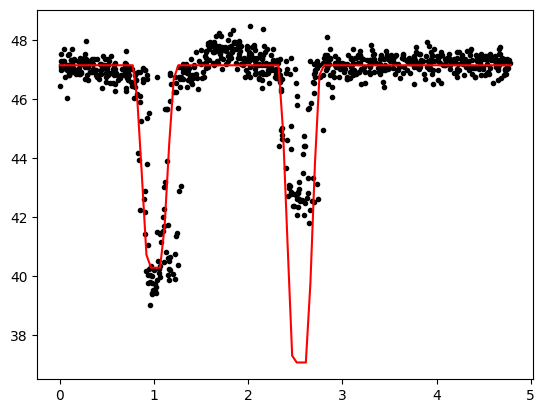

In [6]:
per = period
fase = days % per

esm = EclipsingStarModel( spot=True )
par = [ecc, period, phase, incl, long, 0.2, 0.1, f1, f2, 0.0, 0.0 ]
#par[3] = -70 * PI / 180
t = numpy.linspace( 0, per, 100 )
yfit = esm.result( t, par )

plt.plot( fase, flux, 'k.' )
plt.plot( t, yfit, 'r-' )
plt.show()


In [7]:
mdl = EclipsingStarModel( spot=True, tides=True )
# pars are ["eccentricity", "period", "phase", "inclination", "longitude", "radius_1", "radius_2", "lumen_1", "lumen_2", "spot"]
#    0.349 4.788 4.649 -1.5707963267948966 0.0 39.81656668384893 7.3420887040078355

mdl.setPrior( 0, JeffreysPrior( limits=[0.2,0.5] ) )
mdl.setPrior( 1, UniformPrior( limits=[per * 0.9999, per * 1.0001] ) )
mdl.setPrior( 2, GaussPrior( center=phase, scale=0.5 ) )
mdl.setPrior( 3, GaussPrior( center=incl, scale=0.5 ) )
mdl.setPrior( 4, GaussPrior( center=long, scale=0.5 ) )
mdl.setPrior( 5, UniformPrior( limits=[0,0.3] ) )
mdl.setPrior( 6, UniformPrior( limits=[0,0.3] ) )
mdl.setPrior( 7, UniformPrior( limits=[0,50] ) )
mdl.setPrior( 8, UniformPrior( limits=[0,50] ) )
mdl.setPrior( 9, UniformPrior( limits=[0,1] ) )
mdl.setPrior( 10, UniformPrior( limits=[0.2,0.8] ) )

Fit all  parameters of
  EclipsingStar 
Using a Gauss error distribution with unknown scale
Moving the walkers with   GalileanEngine  ChordEngine
Iteration     logZ        H       LowL     npar parameters                                   scale
       0  -3.07e+07      4.6  -3.07e+07     12  [    0.350    4.788    2.692    1.425 ...    0.186]
    1000  -2.36e+03     14.6  -2.34e+03     12  [    0.333    4.788    2.050    1.257 ...    0.785]
    2000      -829.     22.9      -806.     12  [    0.303    4.788    1.869    1.329 ...    0.812]
    3000      -525.     31.6      -492.     12  [    0.307    4.788    1.881    1.348 ...    0.565]
    4000      -414.     40.5      -372.     12  [    0.301    4.788    1.943    1.340 ...    0.468]
    5000      -382.     50.0      -331.     12  [    0.301    4.788    1.961    1.342 ...    0.417]
    6000      -360.     58.2      -300.     12  [    0.296    4.788    1.988    1.331 ...    0.391]
    7000      -351.     65.8      -282.     12  [    0.

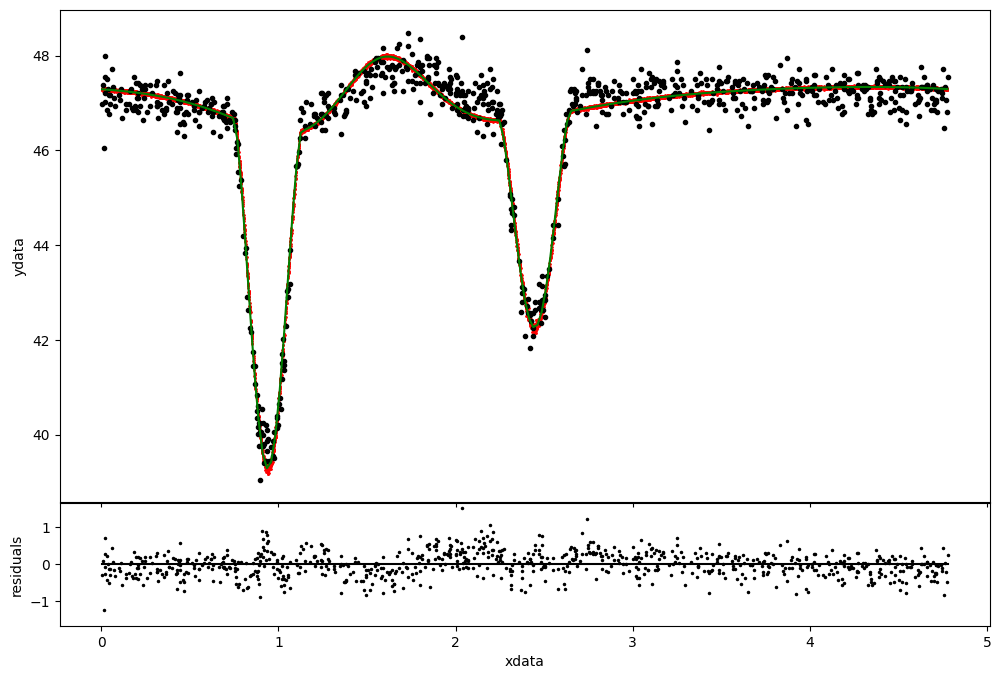

In [8]:
distr = GaussErrorDistribution( limits=[0.1,1] )
engines= ["chord", "galilean"]
ns = NestedSampler( model=mdl, xdata=days, ydata=flux, distribution=distr, verbose=2, seed=134679 )
ns.distribution.constrain = mdl.distanceConstraint
#ns.ensemble = 200
ns.repiter=1000
evid = ns.sample( plot=True, period=1 )


eccentricity :      0.296 +- 0.001
period       :      4.788 +- 0.000 days
phase        :      1.530 +- 0.004 days since 2010.0
inclination  :     76.681 +- 0.089 degrees
longitude    :    345.809 +- 0.309 degrees
radius_1     :      0.186 +- 0.001
radius_2     :      0.147 +- 0.001
lumen_1      :     16.479 +- 0.146 magnitude
lumen_2      :     16.846 +- 0.147 magnitude
spot         :      0.003 +- 0.002
mass_1       :      0.613 +- 0.003


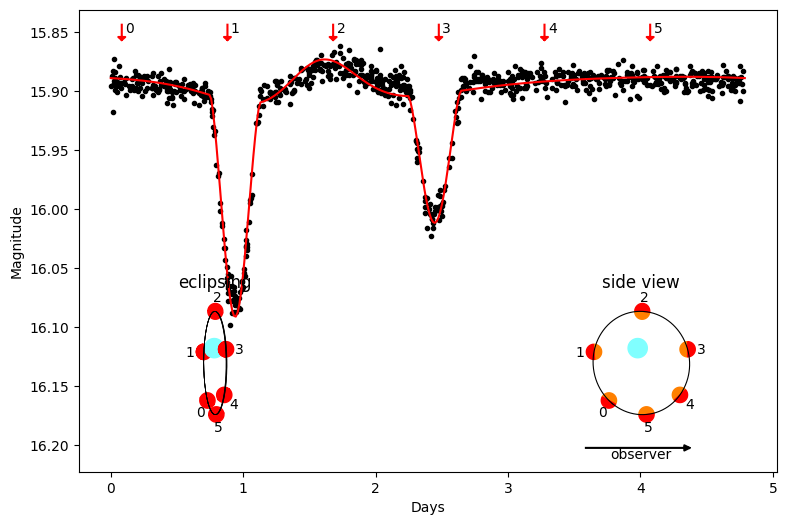

In [9]:
pars = ns.parameters
stdv = ns.stdevs
toMags = 1e-8
mdl.reportParameters( pars, stdv, toMags=toMags )

plotEclipsingStar( mdl, pars, xdata=days%pars[1], ydata=mag, toMags=toMags )